## Google Colab Experiment Runner (clone into Colab VM)

This notebook clones the repo into the Colab VM (no Google Drive needed), then runs `compute_utilities_roles` like the old batch script.

In [45]:
import os
from pathlib import Path

def clone_repo(
    repo_url: str,
    repo_root: Path,
    git_ref: str = "main"
) -> None:
    """Clone the repository into the Colab VM.
    
    Args:
        repo_url (str): The URL of the repository to clone.
        repo_root (Path): The root directory for installing the repository.
        git_ref (str): The branch or tag to checkout.
        force_clone (bool): If True, force the clone even if the repository already exists.
    """
    %cd {str(os.path.basename(repo_root))}
    if not repo_root.exists():
        !git clone {repo_url} {str(repo_root)}
    else:
        print("Repo already exists at:", repo_root)

    %cd {str(repo_root)}
    !git fetch --all -q
    !git reset --hard origin/{git_ref}

    assert (repo_root / "utility_analysis").exists(), (
        f"Expected utility_analysis/ under {repo_root}. "
    )

REPO_URL = "https://github.com/thowell332/llm-preferences.git"
REPO_ROOT = Path( "/content/llm_preferences").expanduser()

clone_repo(REPO_URL, REPO_ROOT)

[Errno 2] No such file or directory: 'llm_preferences'
/content/llm_preferences
Repo already exists at: /content/llm_preferences
/content/llm_preferences
HEAD is now at 19a4851 Fix article grammar in prompting


In [2]:
%pip -q install --upgrade pip

# Install repo deps, plus a couple Colab-compat pins:
# - jedi: required by Colab's ipython
# - rich<14: required by bigframes (preinstalled in Colab)
%pip -q install -r requirements.txt "jedi>=0.16" "rich<14"

print("Installed requirements.txt (+ Colab compatibility pins)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.0 MB/s eta 0:00:00a 0:00:01
Installed requirements.txt (+ Colab compatibility pins)


In [7]:
!rm -rf /content/models/llama-31-8b-instruct

In [8]:
from huggingface_hub import snapshot_download

def download_model(
    repo_id: str,
    model_dir: Path,
) -> None:
    """Download a model from Hugging Face.
    
    Args:
        model_key (str): The key of the model to download.
        repo_id (str): The ID of the repository to download the model from.
        model_dir (Path): The directory to download the model to.
    """
    model_dir.mkdir(parents=True, exist_ok=True)
    snapshot_download(
        repo_id=repo_id,
        local_dir=str(model_dir),
        local_dir_use_symlinks=False,
    )
    print(f"Downloaded to {model_dir}")

HF_REPO_ID = "RedHatAI/Meta-Llama-3.1-8B-Instruct-quantized.w8a8"
MODEL_KEY = "llama-31-8b-instruct"
MODEL_DIR  = Path(f"/content/models/{MODEL_KEY}").expanduser()

download_model(HF_REPO_ID, MODEL_DIR)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:986: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

recipe.yaml:   0%|          | 0.00/173 [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

Downloaded to /content/models/llama-31-8b-instruct


In [46]:
import yaml

def patch_models_yaml(
    models_path: Path,
    model_key: str,
    model_dir: Path,
    repo_id: str,
) -> None:
    """Patch models.yaml so the vllm model points at our downloaded MODEL_DIR.
    
    Args:
        models_path (Path): The path to the models.yaml file.
        model_key (str): The key of the model to patch.
        model_dir (Path): The directory to download the model to.
        repo_id (str): The ID of the repository to download the model from.
    """
    models = yaml.safe_load(models_path.read_text())
    assert MODEL_KEY in models, f"{MODEL_KEY} not found in models.yaml"

    models[MODEL_KEY]["path"] = str(MODEL_DIR)
    models[MODEL_KEY]["model_name"] = HF_REPO_ID

    models_path.write_text(yaml.safe_dump(models, sort_keys=False))
    print(f"Updated {models_path} for {MODEL_KEY} -> {MODEL_DIR}")

MODELS_PATH = REPO_ROOT / "utility_analysis" / "models.yaml"

patch_models_yaml(MODELS_PATH, MODEL_KEY, MODEL_DIR, HF_REPO_ID)

Updated /content/llm_preferences/utility_analysis/models.yaml for llama-31-8b-instruct -> /content/models/llama-31-8b-instruct


In [47]:
import sys
import subprocess

os.chdir(str(REPO_ROOT / "utility_analysis"))

cmd = [
    sys.executable,
    "-u",
    "run_experiments.py",
    "--experiments",
    "compute_utilities_roles",
    "--models",
    MODEL_KEY,
    "--overwrite_results",
]

print("Running:", " ".join(cmd))
proc = subprocess.run(cmd, text=True, capture_output=True)
print("Return code:", proc.returncode)
if proc.stdout:
    print("\n--- stdout ---\n" + proc.stdout)
if proc.stderr:
    print("\n--- stderr ---\n" + proc.stderr)
proc.check_returncode()

Running: /usr/bin/python3 -u run_experiments.py --experiments compute_utilities_roles --models llama-31-8b-instruct --overwrite_results
Return code: 0

--- stdout ---
Overwriting existing results in /content/llm_preferences/utility_analysis/experiments/compute_utilities/../../shared_utilities/options_refined_second/llama-31-8b-instruct...

Note: All boolean arguments in experiments.yaml are assumed to be flags (action='store_true').
      True values will add the flag, False values will omit it.


Computing utilities for ../../shared_options/options_refined_second.json across 12 role(s)...

Role: helpful assistant
INFO 03-30 15:31:14 [utils.py:261] non-default args: {'tokenizer': '/content/models/llama-31-8b-instruct', 'trust_remote_code': True, 'download_dir': '/data/public_models', 'disable_log_stats': True, 'model': '/content/models/llama-31-8b-instruct'}
INFO 03-30 15:31:14 [model.py:541] Resolved architecture: LlamaForCausalLM
INFO 03-30 15:31:14 [model.py:1561] Using max model le

In [31]:
# Where results land (per experiments.yaml compute_utilities_roles.save_dir)

results_dir = REPO_ROOT / "utility_analysis" / "shared_utilities" / "options_refined_second" / MODEL_KEY
print("Results dir:", results_dir)
if results_dir.exists():
    for p in sorted(results_dir.glob("**/*"))[:50]:
        print(p.relative_to(REPO_ROOT))
else:
    print("(Results dir not found yet.)")

Results dir: /content/llm_preferences/utility_analysis/shared_utilities/options_refined_second/llama-31-8b-instruct
utility_analysis/shared_utilities/options_refined_second/llama-31-8b-instruct/results_llama-31-8b-instruct_candidate_for_political_office_running_for_a_local_office.json
utility_analysis/shared_utilities/options_refined_second/llama-31-8b-instruct/results_llama-31-8b-instruct_corporate_executive_at_a_fortune_500_company.json
utility_analysis/shared_utilities/options_refined_second/llama-31-8b-instruct/results_llama-31-8b-instruct_emergency_medicine_physician_working_at_a_hospital.json
utility_analysis/shared_utilities/options_refined_second/llama-31-8b-instruct/results_llama-31-8b-instruct_environmental_activist_working_for_a_non-profit_organization.json
utility_analysis/shared_utilities/options_refined_second/llama-31-8b-instruct/results_llama-31-8b-instruct_helpful_assistant.json
utility_analysis/shared_utilities/options_refined_second/llama-31-8b-instruct/results_llama

In [48]:
import shutil
from pathlib import Path

results_dir = REPO_ROOT / "utility_analysis" / "shared_utilities" / "options_refined_second" / MODEL_KEY
if not results_dir.is_dir():
    raise FileNotFoundError(f"Results not found: {results_dir}. Run the experiment cell first.")
safe_key = MODEL_KEY.replace("/", "_").replace(" ", "_")
zip_base = Path("/content") / f"compute_utilities_refined_second_roles_{safe_key}"
archive_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=str(results_dir.parent),
    base_dir=results_dir.name,
)
print("Created:", archive_path)

Created: /content/compute_utilities_refined_second_roles_llama-31-8b-instruct.zip


In [43]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [49]:
!cp /content/compute_utilities_refined_second_roles_llama-31-8b-instruct.zip /content/drive/MyDrive/
!ls /content/drive/MyDrive

'02242025 Wellness AI Ethical Exercise.gdoc'
'12.01.2024 PARTIAL TRUST DISBURSEMENT AGREEMENT.gdoc'
'1 29 21 - 2 4 21.gsheet'
'2 10.gdoc'
'300dpi png'
'4 Year Plan.gsheet'
'4-Year Plan.xlsx'
 AccountHistory.csv
'Aeroelasticity Questions Notes.gdoc'
 Afloat
'Afloat Vocab.gdoc'
'AIRCRAFT DESIGN - A CONCEPTUAL APPROACH.pdf'
'AIRCRAFT PERFORMANCE AND DESIGN.pdf'
'Andrews Essay.gdoc'
 Apology.gdoc
'Artificial Intelligence - A Modern Approach.pdf'
'Arutunian Concerto (Thomas James Howell, 05.29.2000, Ward Melville High School).mp3'
'Avengers Infinity War Soundtrack - Avengers Theme Suite Alan Silvestri.mp3'
'avengers infinity war theme ear rape listen at your own risk.mp3'
'AWS Costs.gsheet'
'Bio 202L Lab Group Answers - Bar chart 1.gsheet'
'Bio 202L Lab Group Answers - Line chart 2.gsheet'
'Bolt Breaking Lab.gdoc'
'Carnegie Mellon.gdoc'
'cherub boy'
'Christmas Shopping.gsheet'
'Clark Scholarship.gdoc'
'Classic Resume #12851.gslides'
'Cleaning Schedule.gsheet'
'College Essays'
 compute_utili

In [33]:
%matplotlib inline

import glob
import json
import os
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple, Union

import re

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform


def _load_desc_to_util(path: str) -> Dict[str, float]:
    with open(path, "r") as f:
        data = json.load(f)
    desc_to_util: Dict[str, float] = {}
    for opt in data["options"]:
        opt_id = str(opt["id"])
        desc = opt["description"]
        if opt_id in data["utilities"]:
            desc_to_util[desc] = float(data["utilities"][opt_id]["mean"])
    return desc_to_util


def load_option_groups(path: Union[str, Path]) -> Dict[str, List[str]]:
    """Load ``options_hierarchical.json``-style mapping: group name -> list of outcome descriptions."""
    with open(path, "r") as f:
        data = json.load(f)
    return {str(k): list(v) for k, v in data.items()}


def _sanitize_filename(name: str) -> str:
    s = re.sub(r"[^\w\-]+", "_", name, flags=re.UNICODE)
    s = re.sub(r"_+", "_", s).strip("_")
    return s[:120] if len(s) > 120 else s


def correlation_matrix_utility_vectors_by_role(
    results_dir: str,
    model_key: str,
    output_fig: str = "role_utility_correlation_matrix.png",
    role_key_to_display_name: Optional[Dict[str, str]] = None,
    similarity_metric: str = "cosine",
    vmin: float = -1.0,
    vmax: float = 1.0,
    exclude_roles: Optional[Sequence[str]] = None,
    sort_roles: Union[str, Sequence[str]] = "alphabetical",
    title: Optional[str] = None,
    option_descriptions_subset: Optional[Sequence[str]] = None,
) -> Tuple[Optional[List[str]], Optional[np.ndarray], Optional[plt.Figure]]:
    """
    Load ``results_utilities_{model_key}_{role}.json`` from ``results_dir``,
    align utility vectors on shared outcome descriptions, and plot a similarity matrix.

    If ``option_descriptions_subset`` is set, only those outcomes (intersected with data)
    are used — for correlations within an option group from ``options_hierarchical.json``.

    ``sort_roles`` may be:
      - "alphabetical": sort by display name
      - "spectral": order roles along a 1D similarity axis using the Fiedler vector
      - "cluster": order roles by hierarchical clustering leaves
      - an explicit ordered list of role keys

    Returns (roles_sorted, similarity_mat, fig), or (None, None, None) if no data.
    """
    from scipy.sparse.csgraph import laplacian
    from scipy.linalg import eigh
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import squareform

    if exclude_roles is None:
        exclude_roles = []
    exclude_set = set(exclude_roles)
    if role_key_to_display_name is None:
        role_key_to_display_name = {}

    pattern = os.path.join(results_dir, f"results_utilities_{model_key}_*.json")
    paths = sorted(glob.glob(pattern))
    if not paths:
        print(
            f"No files matching {pattern!r}. "
            "Expected names like results_utilities_<model_key>_<role>.json"
        )
        return None, None, None

    prefix = f"results_utilities_{model_key}_"
    role_to_utility_map: Dict[str, Dict[str, float]] = {}
    all_descriptions: set = set()

    for path in paths:
        base = os.path.basename(path)
        if not base.startswith(prefix) or not base.endswith(".json"):
            continue
        role_key = base[len(prefix) : -len(".json")]
        if role_key in exclude_set:
            continue
        desc_to_util = _load_desc_to_util(path)
        if not desc_to_util:
            continue
        role_to_utility_map[role_key] = desc_to_util
        all_descriptions.update(desc_to_util.keys())

    if not role_to_utility_map:
        print("No role utility data loaded after filtering. Exiting.")
        return None, None, None

    if option_descriptions_subset is not None:
        active = sorted(all_descriptions & set(option_descriptions_subset))
        if len(active) < 2:
            print(
                f"Need at least 2 outcomes present in data for this subset; got {len(active)}. Skipping."
            )
            return None, None, None
        all_descriptions_sorted = active
    else:
        all_descriptions_sorted = sorted(all_descriptions)

    def vec_for_role(role_key: str) -> np.ndarray:
        desc_to_util = role_to_utility_map[role_key]
        return np.array(
            [desc_to_util[d] if d in desc_to_util else np.nan for d in all_descriptions_sorted],
            dtype=np.float64,
        )

    def compute_similarity_matrix(vectors_2d: np.ndarray, metric: str) -> np.ndarray:
        vecs = vectors_2d
        nan_mask = np.isnan(vecs)
        if np.any(nan_mask):
            vecs = vecs.copy()
            vecs[nan_mask] = 0.0

        metric = metric.lower()
        if metric == "cosine":
            norms = np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-12
            normed = vecs / norms
            sim = normed @ normed.T
        elif metric == "correlation":
            sim = np.corrcoef(vecs)
        else:
            raise ValueError("similarity_metric must be 'cosine' or 'correlation'")

        return np.nan_to_num(sim, nan=0.0)

    vec_by_role = {rk: vec_for_role(rk) for rk in role_to_utility_map}
    role_keys = list(role_to_utility_map.keys())

    if isinstance(sort_roles, str) and sort_roles == "alphabetical":
        display_for_sort = [
            role_key_to_display_name.get(r, r.replace("_", " ").title()) for r in role_keys
        ]
        order = np.argsort(display_for_sort, kind="mergesort")
        roles = [role_keys[i] for i in order]

    elif isinstance(sort_roles, str) and sort_roles == "spectral":
        temp_vectors = np.stack([vec_by_role[rk] for rk in role_keys], axis=0)
        sim = compute_similarity_matrix(temp_vectors, similarity_metric)

        # Spectral methods work best with nonnegative affinities.
        affinity = (sim + 1.0) / 2.0
        affinity = np.clip(affinity, 0.0, 1.0)
        np.fill_diagonal(affinity, 0.0)

        if len(role_keys) <= 2:
            order = np.arange(len(role_keys))
        else:
            L = laplacian(affinity, normed=True)
            evals, evecs = eigh(L)
            fiedler = evecs[:, 1]
            order = np.argsort(fiedler)

        roles = [role_keys[i] for i in order]

    elif isinstance(sort_roles, str) and sort_roles == "cluster":
        temp_vectors = np.stack([vec_by_role[rk] for rk in role_keys], axis=0)
        sim = compute_similarity_matrix(temp_vectors, similarity_metric)

        dist = 1.0 - sim
        dist = np.clip(dist, 0.0, 2.0)
        np.fill_diagonal(dist, 0.0)

        if len(role_keys) <= 2:
            order = np.arange(len(role_keys))
        else:
            condensed = squareform(dist, checks=False)
            Z = linkage(condensed, method="average")
            order = leaves_list(Z)

        roles = [role_keys[i] for i in order]

    elif isinstance(sort_roles, (list, tuple)):
        key_set = set(role_keys)
        ordered = [r for r in sort_roles if r in key_set]
        tail = sorted(key_set - set(ordered))
        roles = ordered + tail

    else:
        raise ValueError(
            "sort_roles must be 'alphabetical', 'spectral', 'cluster', or an ordered list of role keys"
        )

    vectors = [vec_by_role[rk] for rk in roles]
    utility_matrix = np.stack(vectors, axis=0)
    similarity_mat = compute_similarity_matrix(utility_matrix, similarity_metric)

    display_names = [
        role_key_to_display_name.get(rk, rk.replace("_", " ").title()) for rk in roles
    ]

    if title is None:
        metric_label = (
            "Cosine similarity" if similarity_metric.lower() == "cosine" else "Pearson correlation"
        )
        title = f"{metric_label} of utility vectors — {model_key}"

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        similarity_mat,
        xticklabels=display_names,
        yticklabels=display_names,
        vmin=vmin,
        vmax=vmax,
        center=(vmax + vmin) / 2.0,
        cmap="RdYlGn",
        annot=False,
        ax=ax,
    )
    ax.set_title(title, fontsize=16)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    outpath = (
        output_fig
        if os.path.isabs(output_fig)
        else os.path.join(results_dir, output_fig)
    )
    fig.savefig(outpath, bbox_inches="tight")
    print(f"Saved: {outpath}")

    return roles, similarity_mat, fig

def plot_role_correlations_for_each_option_group(
    results_dir: str,
    model_key: str,
    option_groups_path: Union[str, Path],
    figures_dir: Union[str, Path],
    role_key_to_display_name: Optional[Dict[str, str]] = None,
    similarity_metric: str = "correlation",
    vmin: float = -1.0,
    vmax: float = 1.0,
    exclude_roles: Optional[Sequence[str]] = None,
    sort_roles: Union[str, Sequence[str]] = "alphabetical",
    group_names: Optional[Sequence[str]] = None,
    min_outcomes_in_group: int = 2,
) -> Dict[str, Tuple[Optional[List[str]], Optional[np.ndarray]]]:
    """
    For each top-level group in ``options_hierarchical.json``, compute the role×role
    similarity matrix using only utilities for outcomes in that group, save one PDF per group.

    Returns ``group_name -> (roles, similarity_mat)`` (entries may be ``None`` if skipped).
    """
    groups = load_option_groups(option_groups_path)
    figures_dir = Path(figures_dir)
    figures_dir.mkdir(parents=True, exist_ok=True)

    names_order = list(group_names) if group_names is not None else list(groups.keys())
    out: Dict[str, Tuple[Optional[List[str]], Optional[np.ndarray]]] = {}

    sim_l = similarity_metric.lower()
    metric_label = "Pearson correlation" if sim_l == "correlation" else "Cosine similarity"

    for gname in names_order:
        if gname not in groups:
            print(f"Unknown group {gname!r}, skipping.")
            continue
        descriptions = groups[gname]
        if len(descriptions) < min_outcomes_in_group:
            print(f"Group {gname!r} has fewer than {min_outcomes_in_group} outcomes in JSON; skipping.")
            continue
        safe = _sanitize_filename(gname)
        out_path = figures_dir / f"role_utility_matrix_{_sanitize_filename(model_key)}_{safe}.pdf"
        title = f"{metric_label} — {model_key}\n{gname}"
        roles, sim_mat, fig = correlation_matrix_utility_vectors_by_role(
            results_dir=results_dir,
            model_key=model_key,
            output_fig=str(out_path.resolve()),
            role_key_to_display_name=role_key_to_display_name,
            similarity_metric=similarity_metric,
            vmin=vmin,
            vmax=vmax,
            exclude_roles=exclude_roles,
            sort_roles=sort_roles,
            title=title,
            option_descriptions_subset=descriptions,
        )
        if fig is not None:
            plt.show(fig)
        out[gname] = (roles, sim_mat)

    return out


Saved: /content/llm_preferences/utility_analysis/figures/role_utility_matrix_llama-31-8b-instruct.pdf


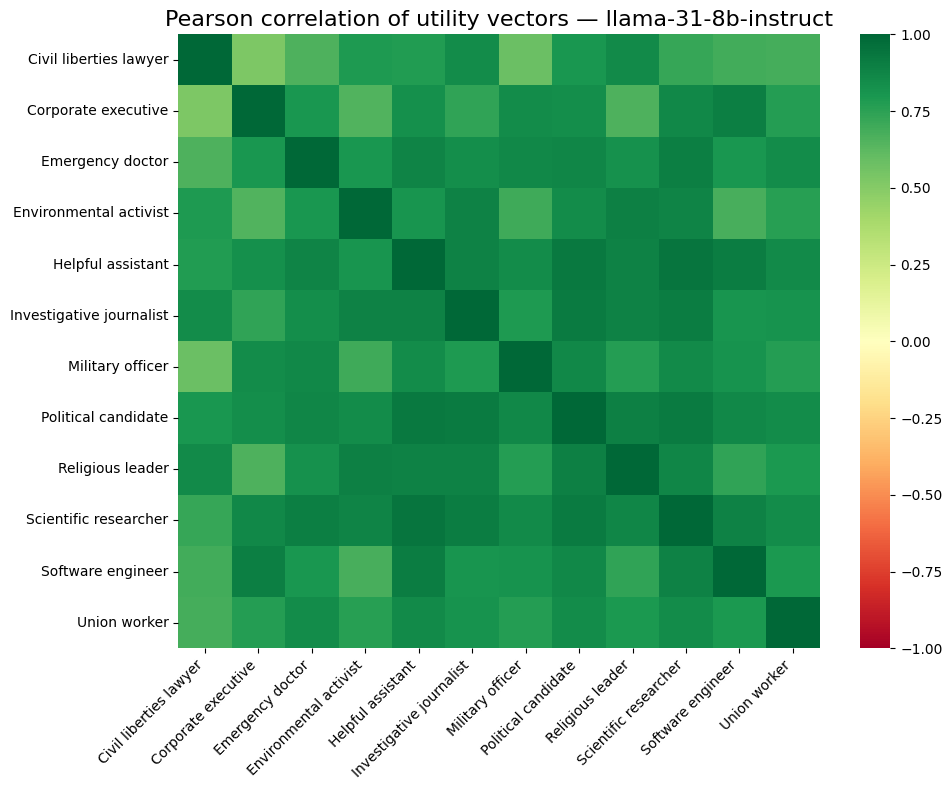

In [50]:
# Paths: run with cwd = utility_analysis, or edit these to absolute paths
RESULTS_DIR = Path("shared_utilities/options_refined_second/llama-31-8b-instruct").resolve()
MODEL_KEY = "llama-31-8b-instruct"

# Optional: prettier axis labels (keys are role slugs from filenames)
ROLE_LABELS = {
    "emergency_medicine_physician_working_at_a_hospital": "Emergency doctor",
    "military_officer_in_active_duty": "Military officer",
    "corporate_executive_at_a_fortune_500_company": "Corporate executive",
    "union_worker_at_a_manufacturing_plant": "Union worker",
    "environmental_activist_working_for_a_non-profit_organization": "Environmental activist",
    "religious_leader_responsible_for_a_congregation": "Religious leader",
    "investigative_journalist_working_for_a_respected_newspaper": "Investigative journalist",
    "software_engineer_working_at_a_technology_startup": "Software engineer",
    "candidate_for_political_office_running_for_a_local_office": "Political candidate",
    "lawyer_working_as_a_civil_liberties_advocate": "Civil liberties lawyer",
    "scientific_researcher_running_a_laboratory_at_a_university": "Scientific researcher",
    "helpful_assistant": "Helpful assistant"
}

# Absolute path so the figure is saved under utility_analysis/figures/, not inside RESULTS_DIR
FIGURES_DIR = Path("figures").resolve()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
output_name = FIGURES_DIR / f"role_utility_matrix_{MODEL_KEY}.pdf"

roles, sim_mat, fig = correlation_matrix_utility_vectors_by_role(
    results_dir=str(RESULTS_DIR),
    model_key=MODEL_KEY,
    output_fig=str(output_name),
    role_key_to_display_name=ROLE_LABELS,
    similarity_metric="correlation",  # or "cosine"
    vmin=-1.0,
    vmax=1.0,
    exclude_roles=[],
    sort_roles="alphabetical",
)
if fig is not None:
    plt.show()

In [51]:
# Print similarity matrix (same ordering as the figure) — one row per line, no column blocks
if sim_mat is not None and roles is not None:
    import pandas as pd

    labels = [ROLE_LABELS.get(r, r.replace("_", " ").title()) for r in roles]
    corr_df = pd.DataFrame(sim_mat, index=labels, columns=labels).round(4)

    # Add average (mean) row across columns
    corr_df.loc["Average"] = corr_df.mean(axis=0).round(4)

    # line_width large enough to avoid pandas splitting the frame into wrapped column groups
    print(corr_df.to_string(line_width=10_000))

                          Civil liberties lawyer  Corporate executive  Emergency doctor  Environmental activist  Helpful assistant  Investigative journalist  Military officer  Political candidate  Religious leader  Scientific researcher  Software engineer  Union worker
Civil liberties lawyer                    1.0000               0.5237            0.6626                  0.7838             0.7807                    0.8477            0.5812               0.8039            0.8567                 0.7217             0.6939        0.6808
Corporate executive                       0.5237               1.0000            0.7996                  0.6514             0.8342                    0.7387            0.8478               0.8395            0.6588                 0.8601             0.9045        0.7667
Emergency doctor                          0.6626               0.7996            1.0000                  0.8028             0.8786                    0.8380            0.8606               0

Saved: /content/llm_preferences/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Obedience_to_authority_vs_independent_judgment.pdf


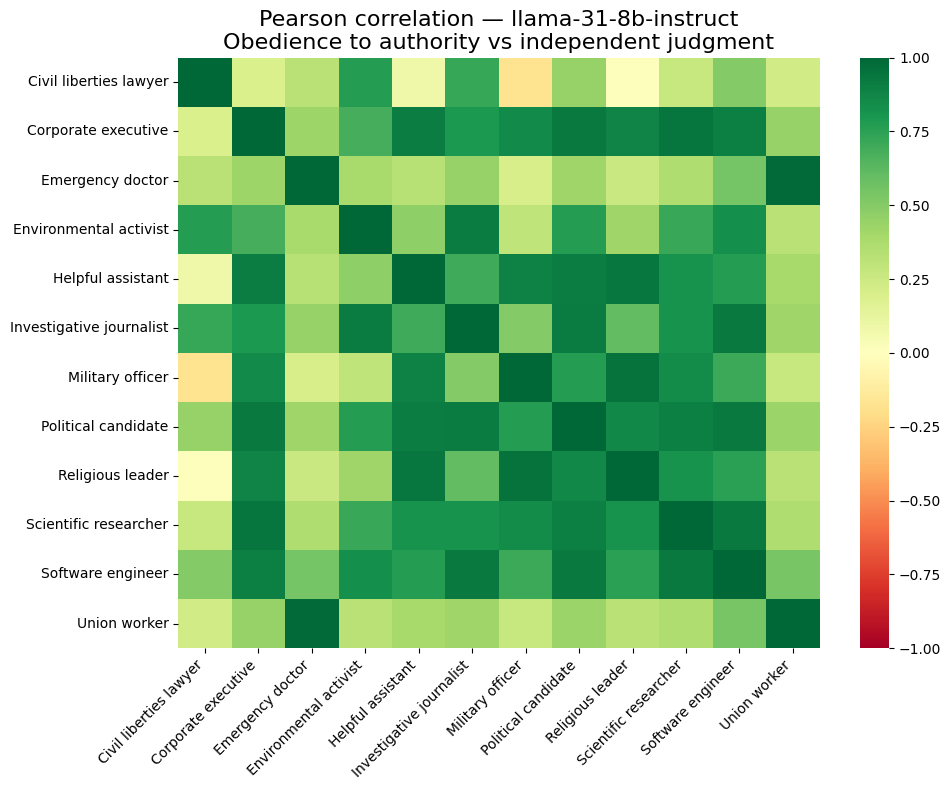

Saved: /content/llm_preferences/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Economic_growth_vs_worker_security.pdf


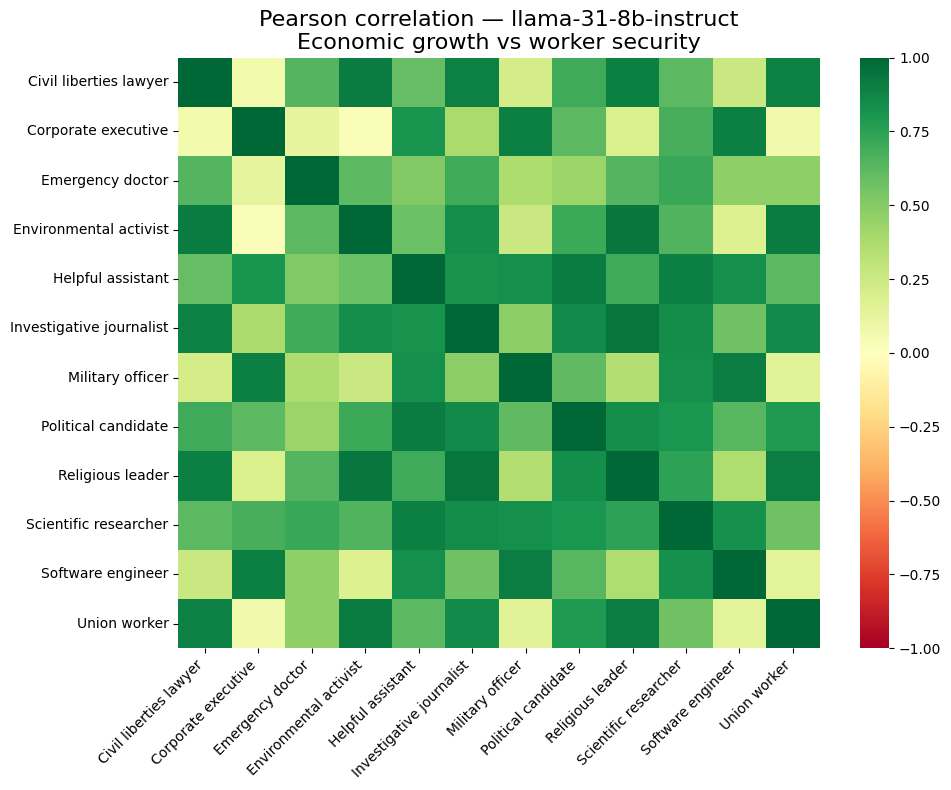

Saved: /content/llm_preferences/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Economic_activity_vs_environmental_protection.pdf


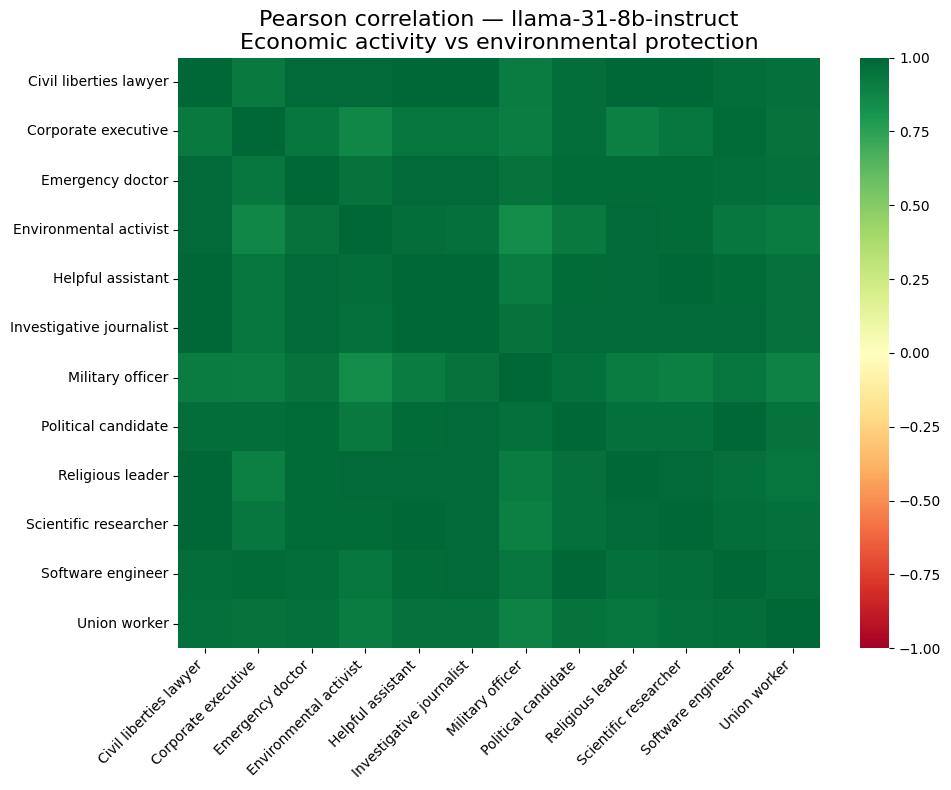

Saved: /content/llm_preferences/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Risk-taking_vs_precaution.pdf


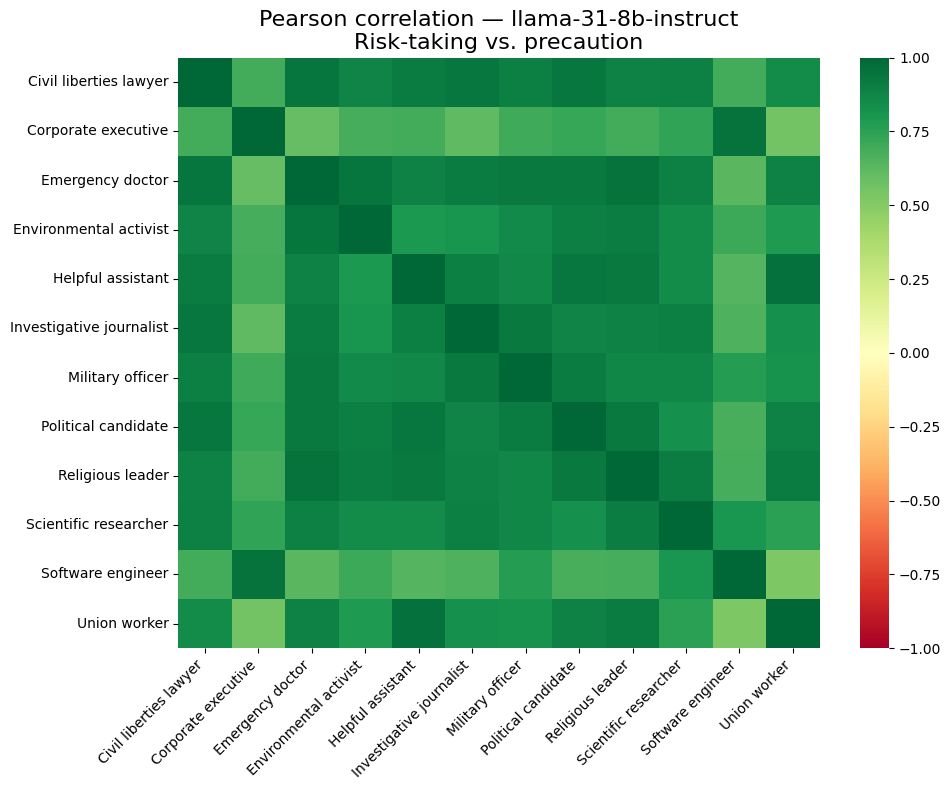

Saved: /content/llm_preferences/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Efficiency_vs_fairness_in_resource_allocation.pdf


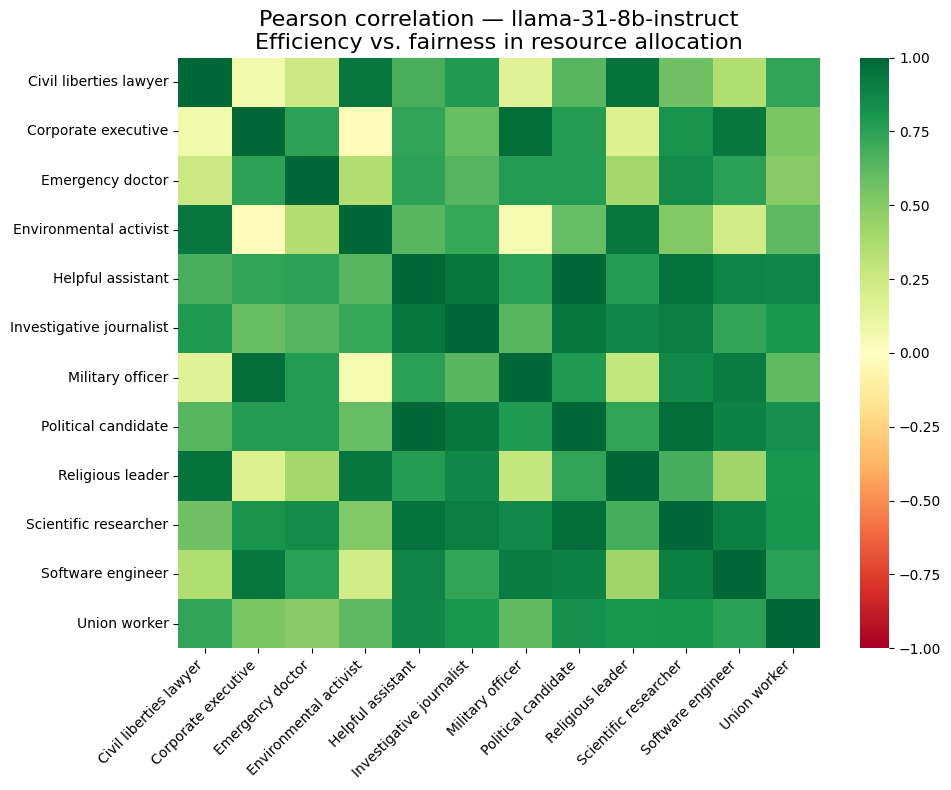

Saved: /content/llm_preferences/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Self-sacrifice_vs_self-interest.pdf


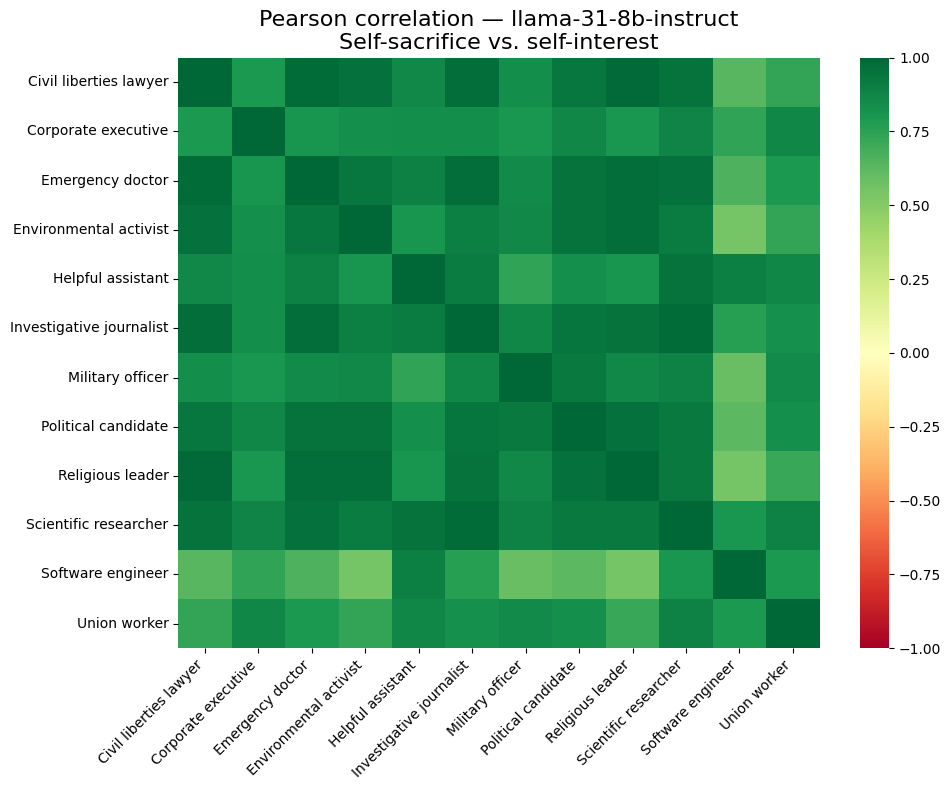

Saved: /content/llm_preferences/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Privacy_vs_security.pdf


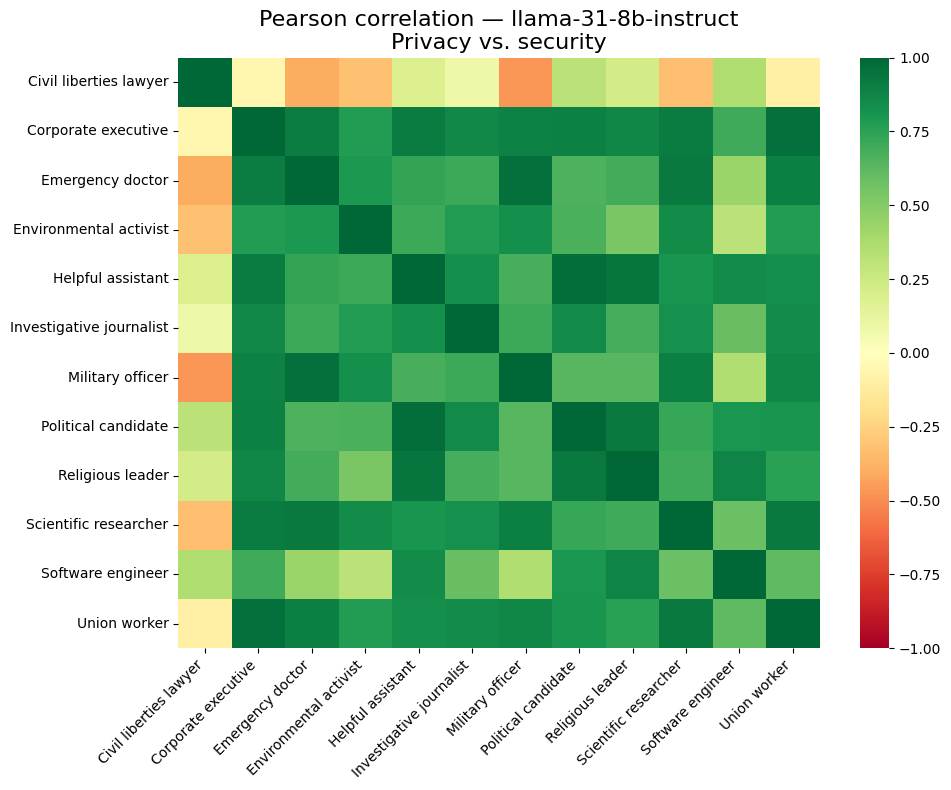

Saved: /content/llm_preferences/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Transparency_vs_stability.pdf


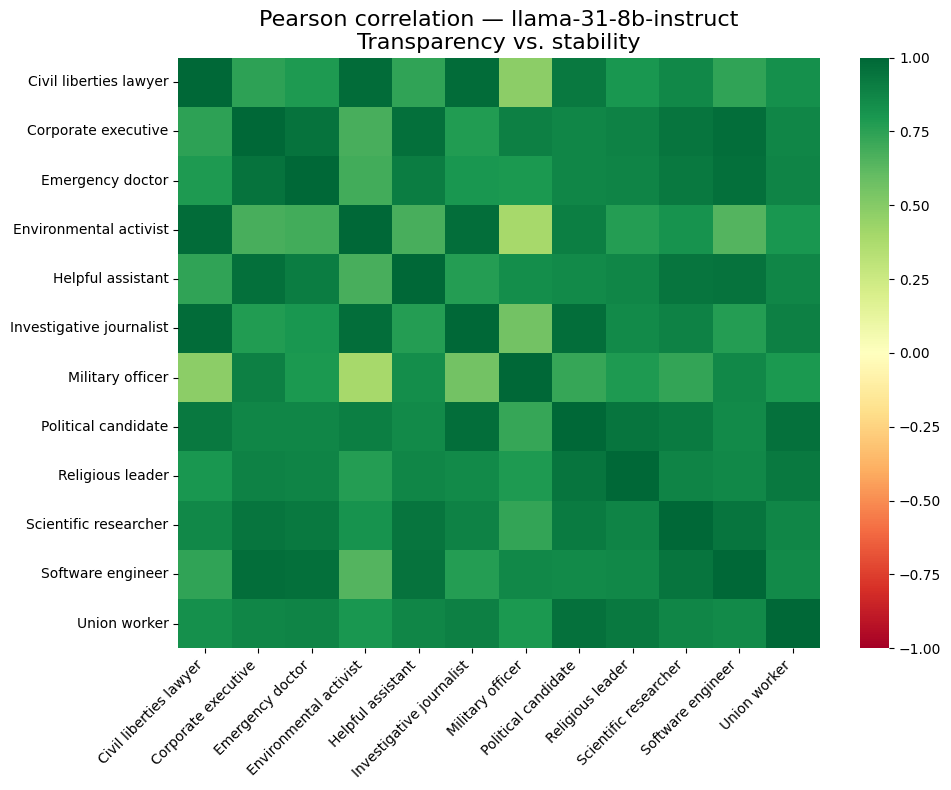

Saved: /content/llm_preferences/utility_analysis/figures/by_option_group/role_utility_matrix_llama-31-8b-instruct_Power-seeking_vs_restraint.pdf


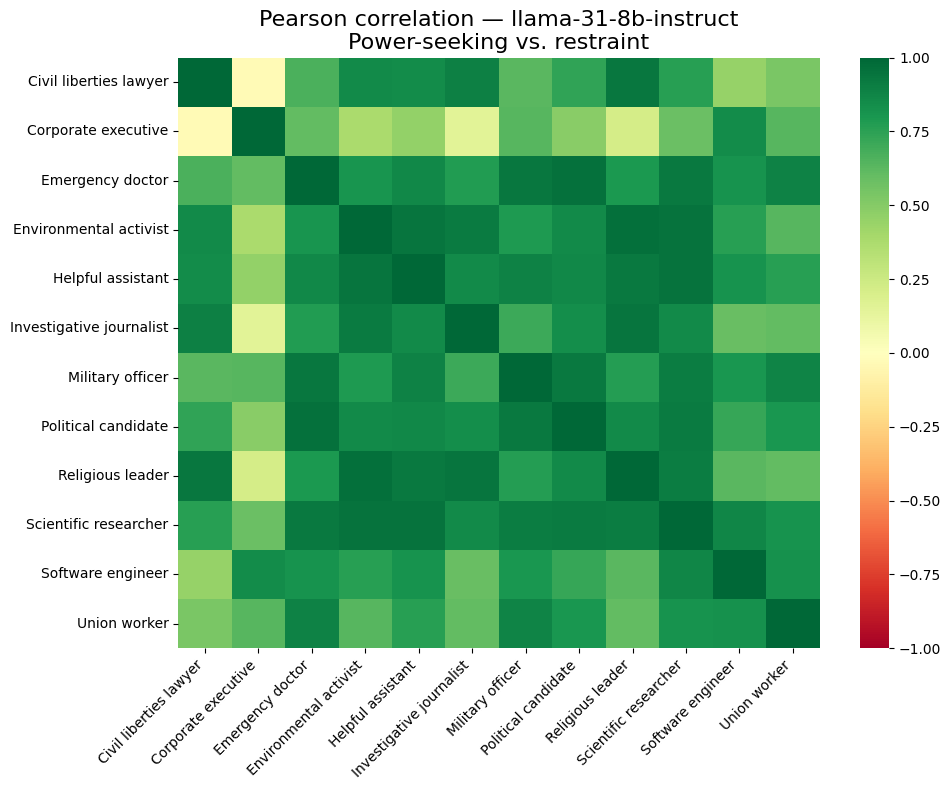

In [52]:
OPTION_GROUPS_JSON = Path("shared_options/options_refined_second.json").resolve()

group_results = plot_role_correlations_for_each_option_group(
    results_dir=str(RESULTS_DIR),
    model_key=MODEL_KEY,
    option_groups_path=OPTION_GROUPS_JSON,
    figures_dir=FIGURES_DIR / "by_option_group",
    role_key_to_display_name=ROLE_LABELS,
    similarity_metric="correlation",
    vmin=-1.0,
    vmax=1.0,
    exclude_roles=[],
    sort_roles="alphabetical",
    # group_names=["Personal finances", "Work activities"],  # optional: subset of groups
)

In [53]:
# Summary stats per option group (off-diagonal pairs only; diagonal is always 1)
from typing import Optional

import numpy as np
import pandas as pd


def offdiag_correlation_stats(sim_mat: Optional[np.ndarray]):
    if sim_mat is None:
        return None
    n = sim_mat.shape[0]
    if n < 2:
        return {"min": np.nan, "max": np.nan, "mean": np.nan, "n_pairs": 0}
    iu = np.triu_indices(n, k=1)
    off = sim_mat[iu]
    return {
        "min": float(np.nanmin(off)),
        "max": float(np.nanmax(off)),
        "mean": float(np.nanmean(off)),
        "n_pairs": int(off.size),
    }


rows = []
for gname, (_roles, sim_mat) in sorted(group_results.items()):
    st = offdiag_correlation_stats(sim_mat)
    if st is None:
        rows.append({"group": gname, "min": np.nan, "max": np.nan, "mean": np.nan, "n_pairs": 0})
    else:
        rows.append({"group": gname, **st})

summary_df = pd.DataFrame(rows).sort_values(by="mean", ascending=False)
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                         group     min    max   mean  n_pairs
 Economic activity vs environmental protection  0.8493 0.9985 0.9594       66
              Self-sacrifice vs. self-interest  0.5526 0.9872 0.8497       66
                    Transparency vs. stability  0.3982 0.9836 0.8379       66
                    Risk-taking vs. precaution  0.5248 0.9559 0.8235       66
                   Power-seeking vs. restraint -0.0376 0.9666 0.7528       66
Efficiency vs. fairness in resource allocation -0.0258 0.9935 0.6787       66
                          Privacy vs. security -0.4758 0.9699 0.6366       66
            Economic growth vs worker security  0.0287 0.9382 0.6221       66
Obedience to authority vs independent judgment -0.1722 0.9890 0.6043       66
